# Project: Verhuuraantallen
### Team: Undefined
### Teamleden:
- **Sebastiaan Westerlaken**
- **Michal Kakol**

# 0. Setup:

### 0.1. Imports:

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Lasso
import warnings
warnings.filterwarnings('ignore')

### 0.2. Data Mining:

In [29]:
df_train = pd.read_csv("../data/train.csv")
df_test = pd.read_csv("../data/test.csv")
df_submission = pd.read_csv("../data/sample_submission.csv")

### 0.3. Data Cleaning:

Data is al schoongemaakt. Er zijn geen null values en data integrity klopt ook door vastgestlde normalisatie van 'temp', 'atemp', 'hum', 'windspeed' en encoding van 'holiday' and 'weathersit'.

In [30]:
print(df_train.info())
print(df_train.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16637 entries, 0 to 16636
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date_hour   16637 non-null  object 
 1   holiday     16637 non-null  int64  
 2   weathersit  16637 non-null  int64  
 3   temp        16637 non-null  float64
 4   atemp       16637 non-null  float64
 5   hum         16637 non-null  float64
 6   windspeed   16637 non-null  float64
 7   cnt         16637 non-null  int64  
dtypes: float64(4), int64(3), object(1)
memory usage: 1.0+ MB
None
            holiday    weathersit          temp         atemp           hum  \
count  16637.000000  16637.000000  16637.000000  16637.000000  16637.000000   
mean       0.028671      1.415580      0.504745      0.482608      0.624756   
std        0.166885      0.637298      0.192369      0.171557      0.193227   
min        0.000000      1.000000      0.020000      0.000000      0.000000   
25%        0.000000 

# 1. EDA:

### Meetniveaus:
- Nominaal: "holiday"
- Ordinaal: "weathersit"
- Continuous/ratio: "temp", "atemp", "hum", "windspeed", "cnt" (target)
- Tijdseries: "date_hour"

Continuous variabelen zijn grotendeels normaal verdeeld, maar "windspeed" is licht rechts-scheef.

### Correlaties en belangrijkste variabelen:
Sterk gecorreleerde variabelen met het target cnt: "temp" 0.43, "hum" -0.36.
Zwakke correlaties: "windspeed" 0.10, "weathersit" -0.12, "holiday" -0.03.
"temp" en "atemp" zijn bijna volledig gecorreleerd, waardoor er sprake is van Multicollinearity en dus "atemp" zou uitgesloten worden bij modeling.

### Tijdseries observaties:
Sampling is hoofdzakelijk per uur als meest voorkomende frequentie is 1 uur, maar er zijn nog 7 andere die zou moeten uniform sampling grbuiken mo ze te kunnen gebruiken bij modelleren.
Data bevat bijna 700 dagen (frequency) met 16.637 samples (number of samples).
- Trend: algemene stijging, met pieken in zomer en vroege herfst (rond 300) en dalen in winter (tussen 50–100). Dus de trend is eigenlijk hierbij een beetje iets tussen echte trend en grote schaal (jaarlijks) seasonality (die kan niet als seasonality gelabeled worden omdat er bestaan niet eens 2 cycles)
- Seizoenspatroon: maandelijkse cycle period is hierbij heel zacht met zachte (maar iets sterkste) wekelijkse cycles er ook. Jaarlijkse patronen zijn observeerbaar, maar omdat er is "slechts" onder 2 jaar data beschikbaar ze kunnen niet gebuikt worden. Ik heb eerder time series data opgezet naar daily om die sneller te kunnen berekenen, omdat het deed te lang door de hoeveelheid van samples (meestal hourly voor bijna 2 jaar). Dit gaaf aan heel slechte seasonality, omdat die vooral per uur aanwezig is, ik heb dit onderzocht door autocorrelatie. Het is ook logisch, omdat het einddoel is om een voorspelling te maken per uur. Uit Het hourly decomposition (in Feature Engineering) blijkt dat de data moest heel erg ge-smooth worden, door hourly seasonality.
- Noise: neemt toe met de tijd, starts rond -50 tot 50, eindigt rond -150 tot 75, wat relatief groter is dan het seizoenspatroon.

# Basis statistiek:
Continuous:
               temp         atemp           hum     windspeed           cnt
count  16637.000000  16637.000000  16637.000000  16637.000000  16637.000000
mean       0.504745      0.482608      0.624756      0.190310    190.477009
std        0.192369      0.171557      0.193227      0.121915    182.026755
min        0.020000      0.000000      0.000000      0.000000      1.000000
25%        0.340000      0.333300      0.470000      0.104500     41.000000
50%        0.520000      0.500000      0.620000      0.194000    143.000000
75%        0.660000      0.621200      0.780000      0.253700    282.000000
max        1.000000      1.000000      1.000000      0.850700    977.000000
Ordinal:
weathersit
1    11078
2     4207
3     1349
4        3
Name: count, dtype: int64
Nominal:
holiday
0    16160
1      477
Name: count, dtype: int64


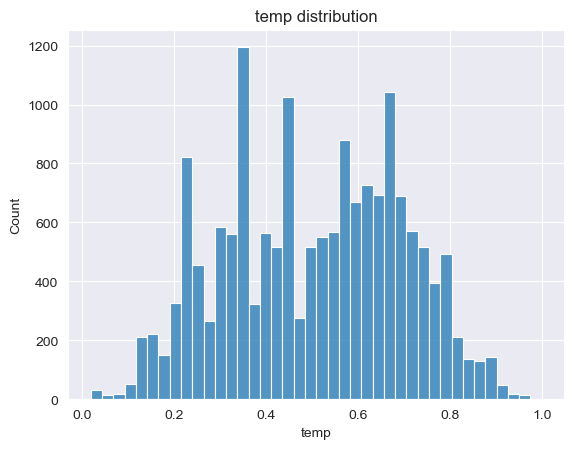

temp: skew=-0.07, kurtosis=-0.91


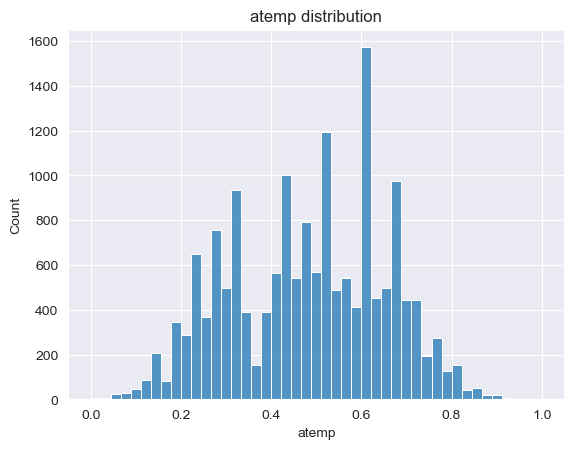

atemp: skew=-0.16, kurtosis=-0.80


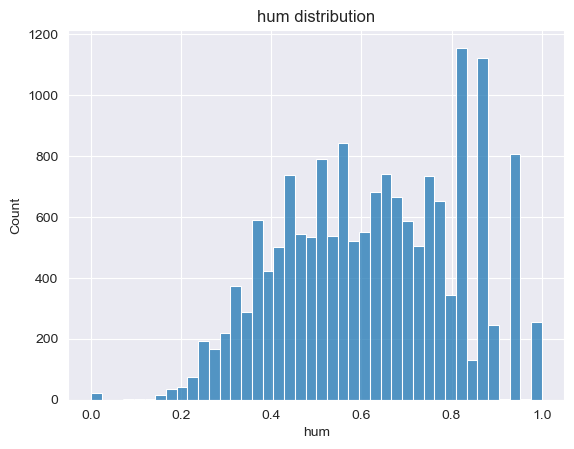

hum: skew=-0.11, kurtosis=-0.83


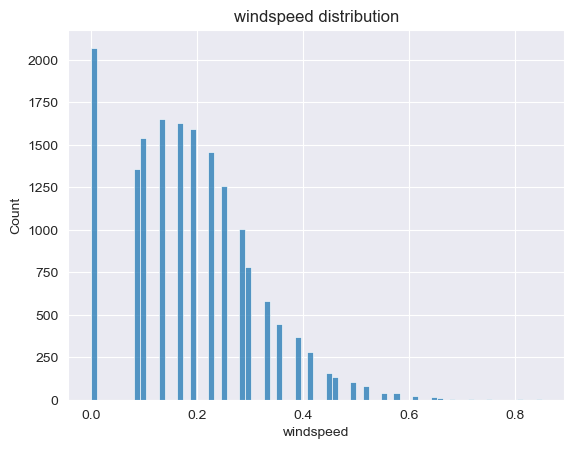

windspeed: skew=0.57, kurtosis=0.60
Spearman (temp vs cnt): rho=0.43, p=0.0000
Spearman (atemp vs cnt): rho=0.43, p=0.0000
Spearman (hum vs cnt): rho=-0.36, p=0.0000
Spearman (windspeed vs cnt): rho=0.13, p=0.0000
Spearman (weathersit vs cnt): rho=-0.12, p=0.0000
Point-Biserial (holiday vs cnt): r=-0.03, p=0.0006


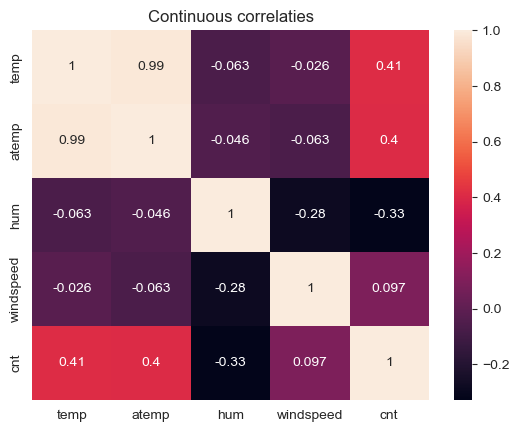

Time series:


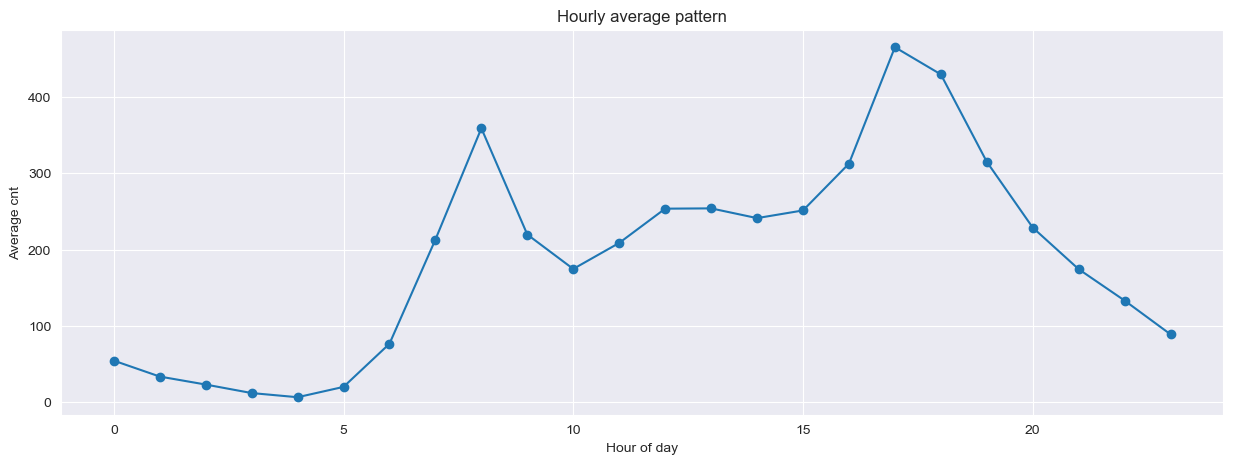

<Figure size 1500x500 with 0 Axes>

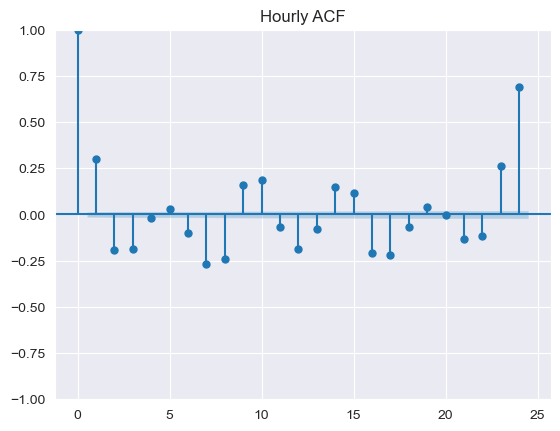

Sampling frequency: <TimedeltaArray>
[              NaT, '0 days 01:00:00', '0 days 02:00:00', '0 days 03:00:00',
 '0 days 13:00:00', '0 days 23:00:00', '0 days 07:00:00', '0 days 14:00:00',
 '1 days 13:00:00']
Length: 9, dtype: timedelta64[ns]
Main Sampling frequency: 0 days 01:00:00
Total samples: 16637
Total time: 699 days 23:00:00


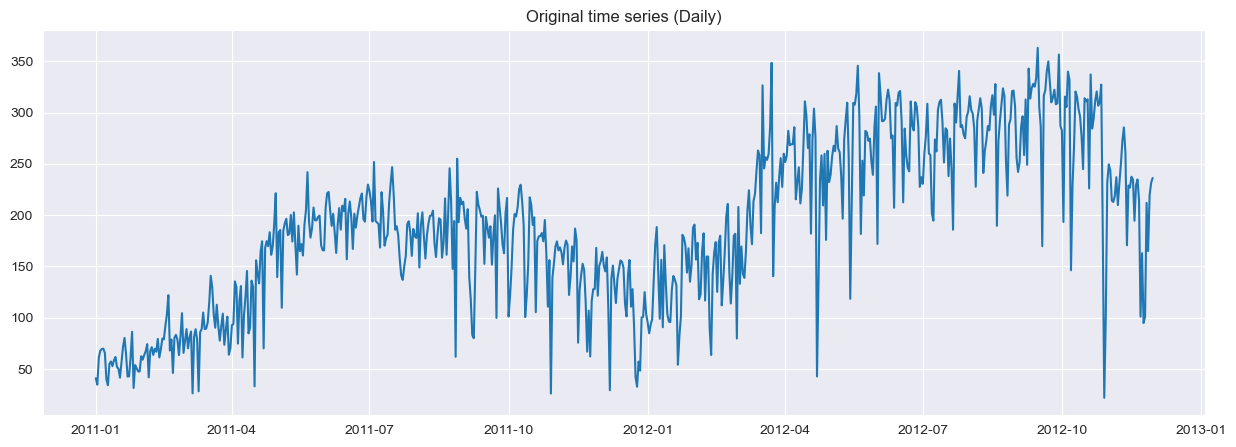

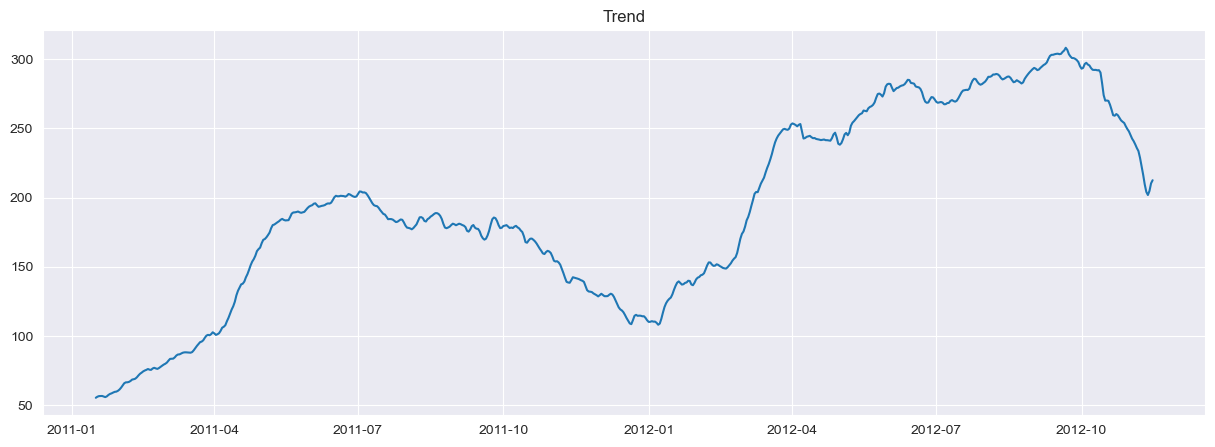

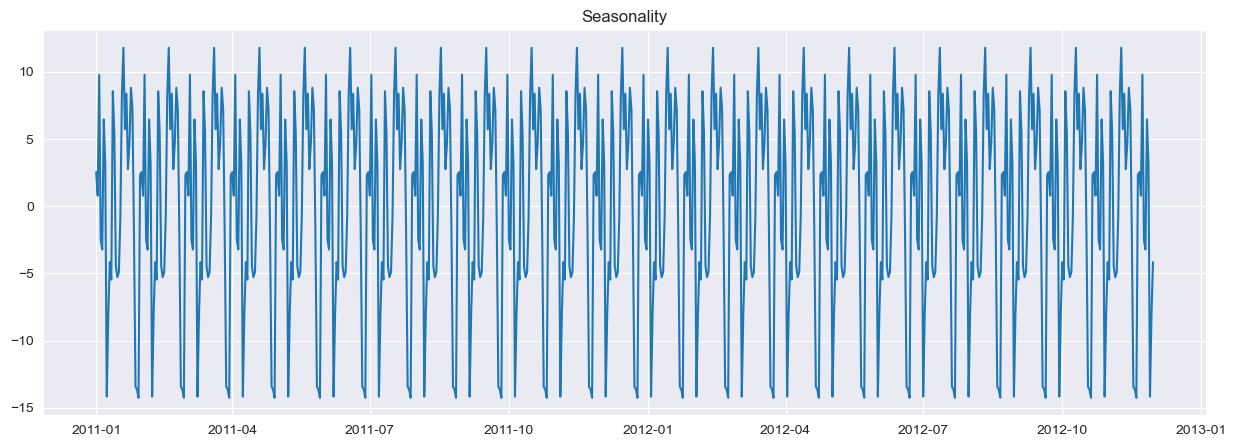

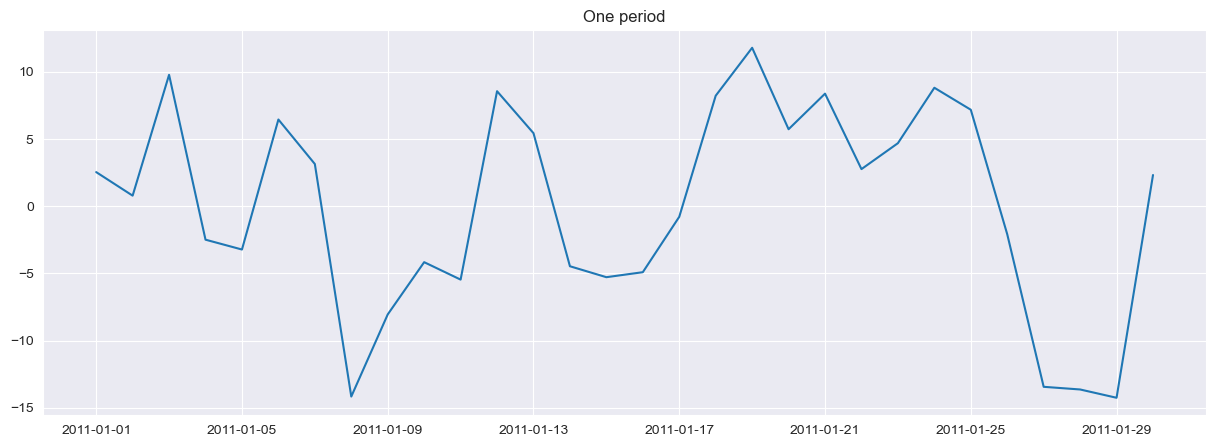

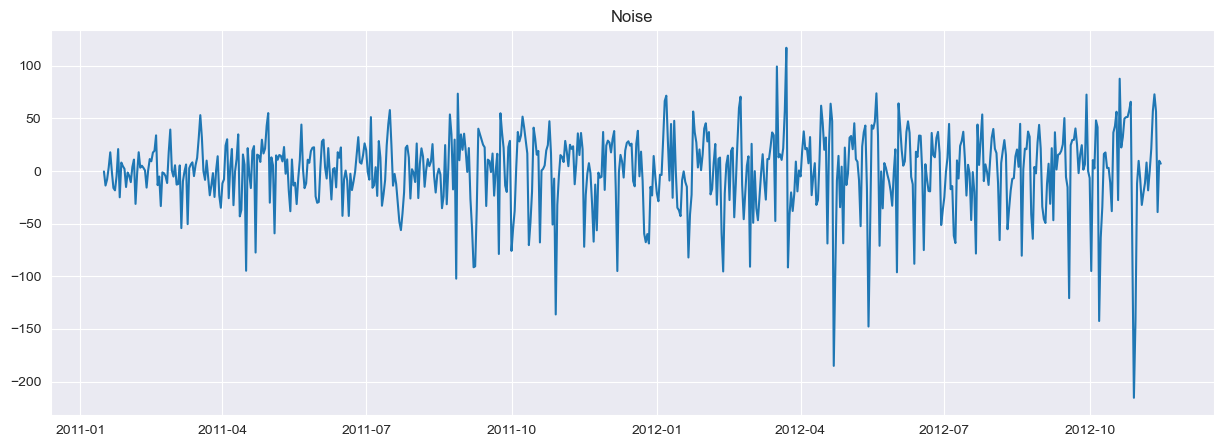

<Figure size 1500x500 with 0 Axes>

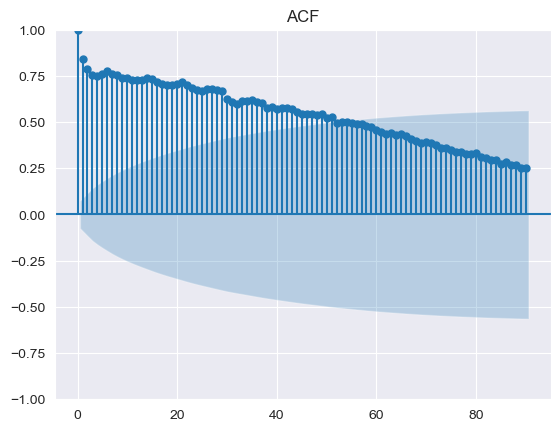

<Figure size 1500x500 with 0 Axes>

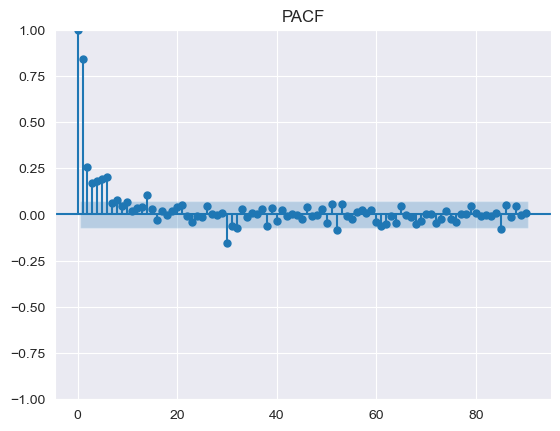

In [31]:
from functions.eda import eda
eda(
    df_train,
    target_col='cnt',
    nominal_cols=['holiday'],
    ordinal_cols=['weathersit'],
    timeseries_col='date_hour'
)

# 2. Time Series Feature Engineering:

### 2.1. Sampling:

In deze stap heb ik de kolom “date_hour” omgezet naar een echt datetime-type en daarna als index gebruikt. Vervolgens heb ik de data opnieuw gesampled naar een vaste frequentie zodat alle tijdstappen even groot zijn. Dit is nodig om time series features te kunnen maken. De data zelf is erg noisy door het hoge frequentie over lange termijn. Daardoor lijkt de messy lijnplot bijna op een crumbled histogram. Om de trend zichtbaar te krijgen moet er daarom vrij zwaar gesmooth worden. Uit de eerdere EDA kwam al naar voren dat de hourly seasonality het sterkst zijn. Wekelijkse en maandelijkse patronen zijn wel haalbaar om uit de data te halen, want die waren al gedeeltelijk zichtbaar in de autocorrelatie en sluiten aan bij de eerste observaties uit de EDA.

<Axes: xlabel='date_hour'>

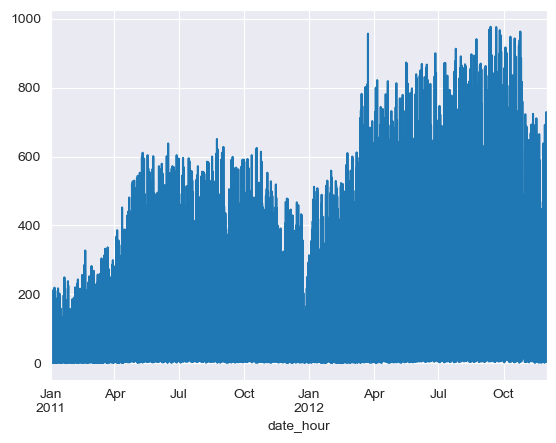

In [32]:
from functions.feature_engineering_timeseries import time_series_setup
df_setup = time_series_setup(df_train, datetime_col='date_hour', uniform_sampling='h') # Every hour
df_setup['cnt'].plot()

### 2.2. Decomposition:

In deze stap gebruik ik een rolling moving average om de data smoother te maken en een duidelijke trend te krijgen. Ik gebruik expres niet seasonal_decompose uit statsmodels, omdat die methode de trend en de daily seasonality tegelijk gladstrijkt. Bij deze dataset zorgt dat ervoor dat de dagelijkse seizoenspatronen worden kwijd geraakt. Door eerst zelf de trend eruit te halen en daarna het gemiddelde per uur van de dag te nemen, worden trend en seasonality apart behandeld. Zo blijft de trend smooth en de seasonal range blijft realistisch. De noise blijft wel zichtbaar, maar het is nu beter te scheiden van de andere componenten. De smoothing window voor de trend staat heel hoog (1000), maar dat is nodig door hoe messy en high frequency de data is. Dit werkt, omdat de seasonal component apart wordt berekend en dus niet beïnvloed wordt door deze sterke smoothing. De seasonality plot zelf is moeilijk leesbaar door de hoge frequentie, maar ik laat hem staan omdat hij wel nuttig is als je lagere frequenties (zoals monthly patterns) wilt testen. Onder de plot laat ik een extracted period zien om een beter beeld te krijgen van een cycle period.

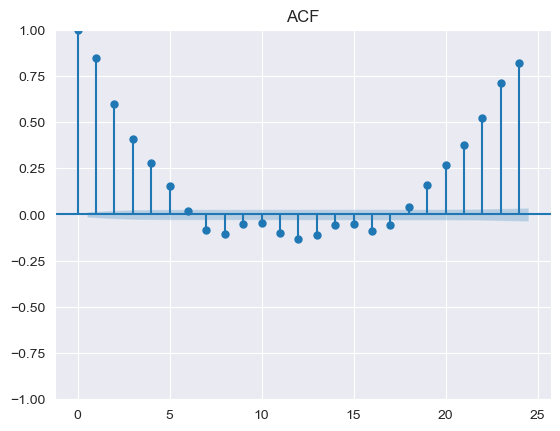

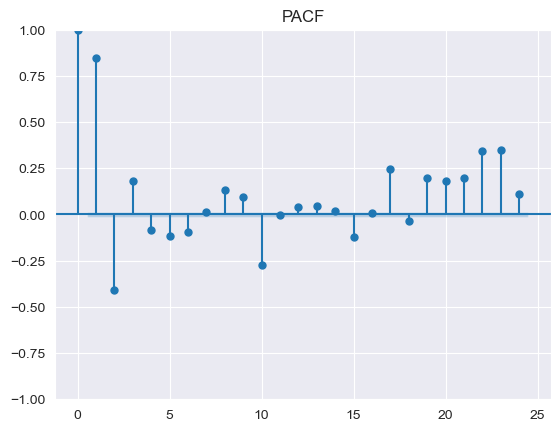

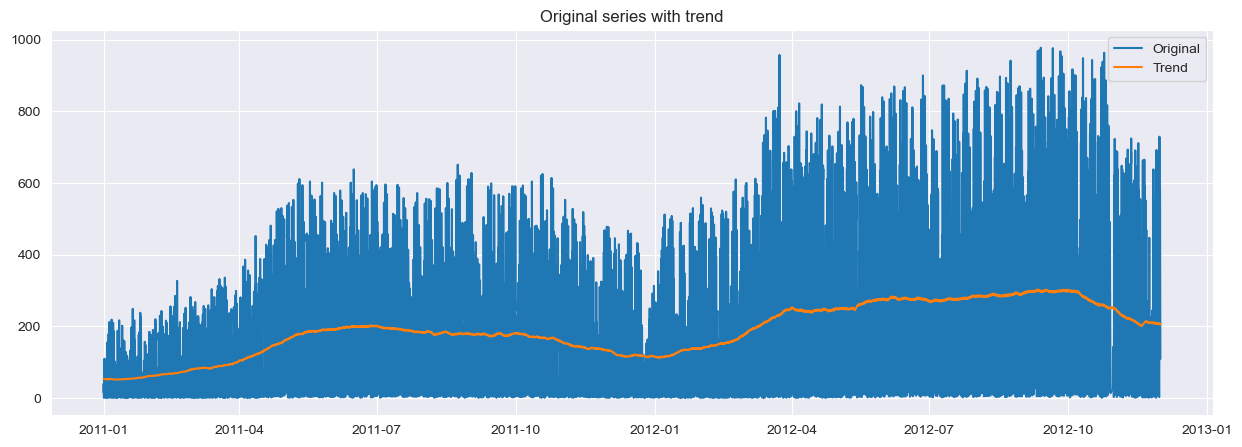

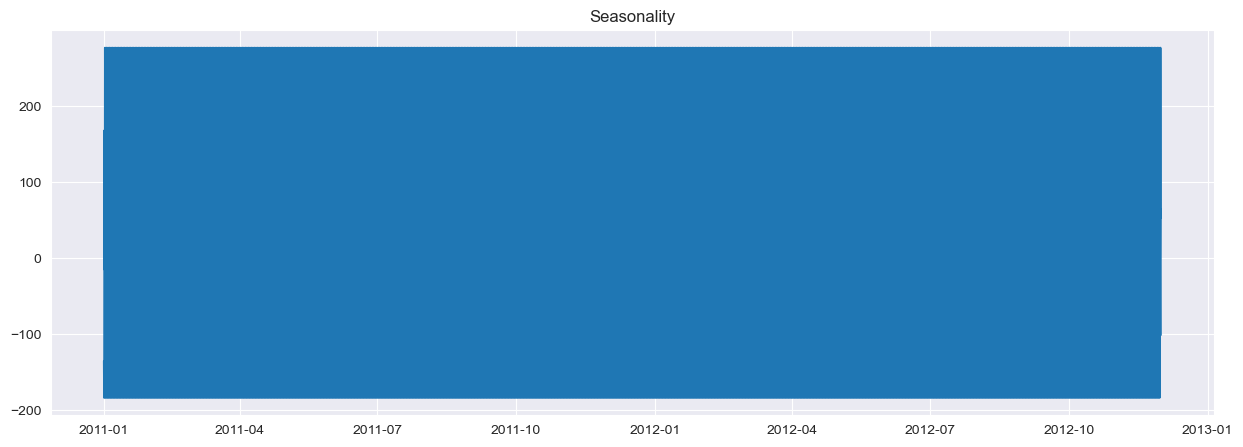

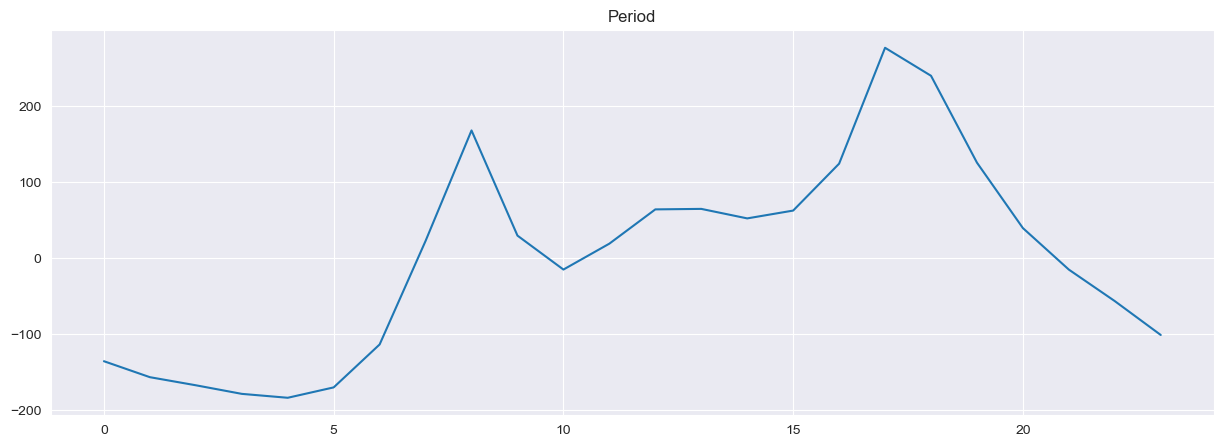

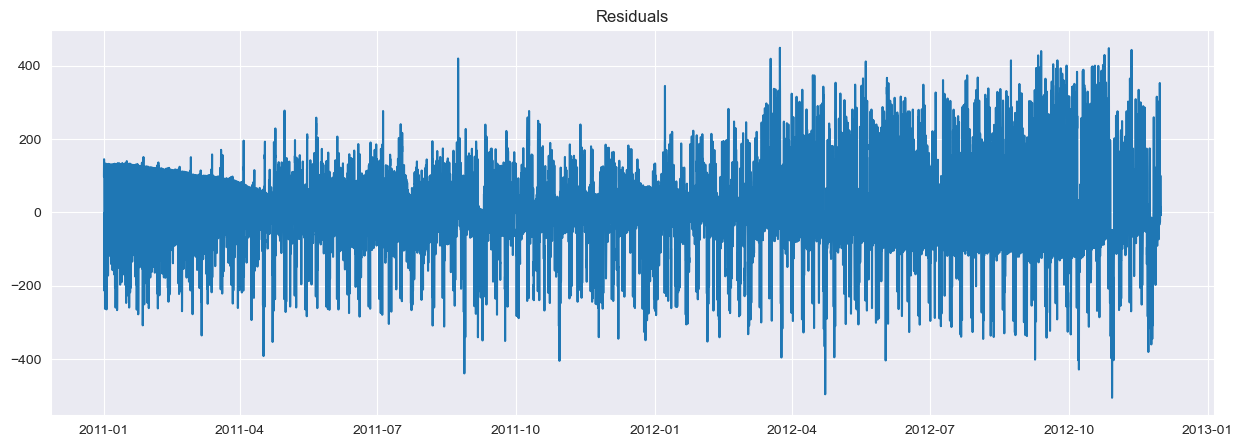

,holiday,weathersit,temp,atemp,hum,windspeed,cnt,trend,seasonal,resid
date_hour,,,,,,,,,,
2011-01-01 00:00:00,0.0,1.0,0.24,0.2879,0.81,0.0000,16.0,53.880000,-135.381726,97.501726
2011-01-01 01:00:00,0.0,1.0,0.22,0.2727,0.80,0.0000,40.0,53.878244,-156.378526,142.500282
2011-01-01 02:00:00,0.0,1.0,0.22,0.2727,0.80,0.0000,32.0,53.852590,-167.021135,145.168545
2011-01-01 03:00:00,0.0,1.0,0.24,0.2879,0.75,0.0000,13.0,53.813121,-178.313156,137.500035
2011-01-01 04:00:00,0.0,1.0,0.24,0.2879,0.75,0.0000,1.0,53.759921,-183.460625,130.700704
...,...,...,...,...,...,...,...,...,...,...
2012-11-30 19:00:00,0.0,1.0,0.32,0.3485,0.66,0.0000,377.0,204.887129,125.718526,46.394345
2012-11-30 20:00:00,0.0,1.0,0.32,0.3485,0.66,0.0000,245.0,204.972222,39.655528,0.372250
2012-11-30 21:00:00,0.0,1.0,0.30,0.3182,0.75,0.0896,183.0,205.137177,-14.920873,-7.216304


In [33]:
from functions.feature_engineering_timeseries import decomposition_featuring
features = decomposition_featuring(
    df_setup,
    target_col='cnt',
    period=24, # 24h cycle window
    lags=24, # 24h autocorrelation window
    trend_smooth=1000 # 1000 samples smoothing window
)
# Merging features to df
df_decomp = df_setup.merge(features, left_index=True, right_index=True)
display(df_decomp)

### 2.3. Linearity:

Er is geen linear of exponentieel verband gevonden in de drie hoofdperioden dat het waard zou zijn om aparte features voor te maken. Ik had gehoopt dat ten minste de weekly lag dit patroon zou laten zien (groei richting het weekend met piek in het weekend), maar door de extreem hoge range over het hele jaar lijkt het in de visualisaties vlak.

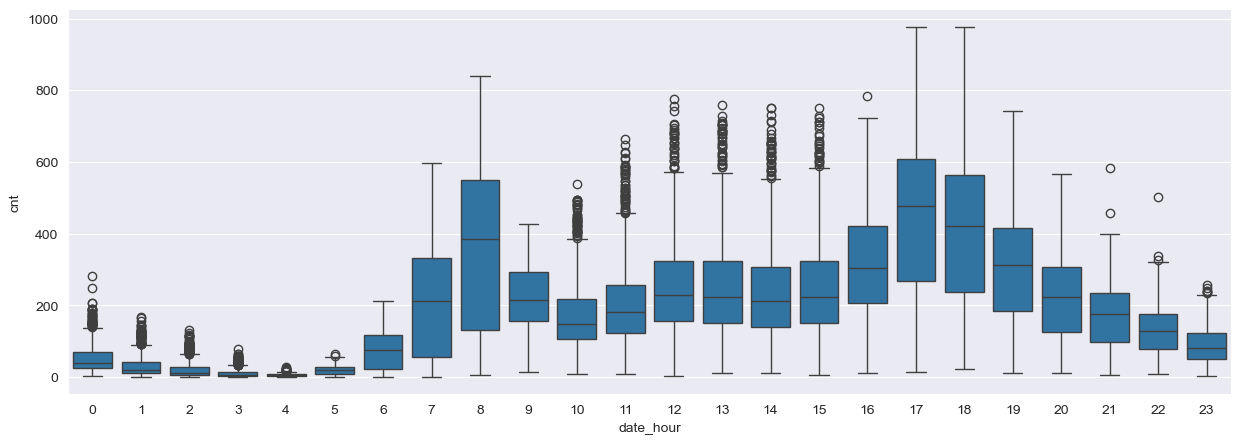

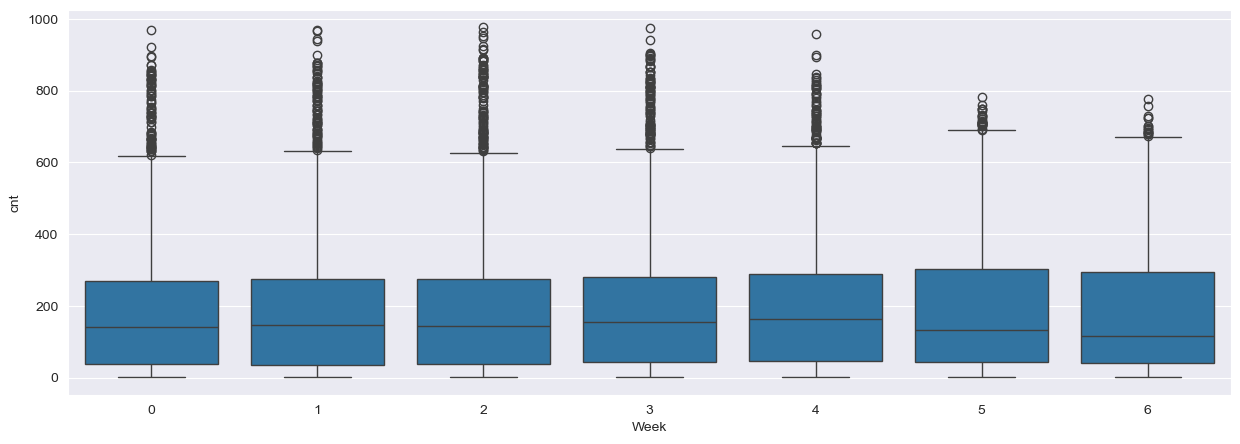

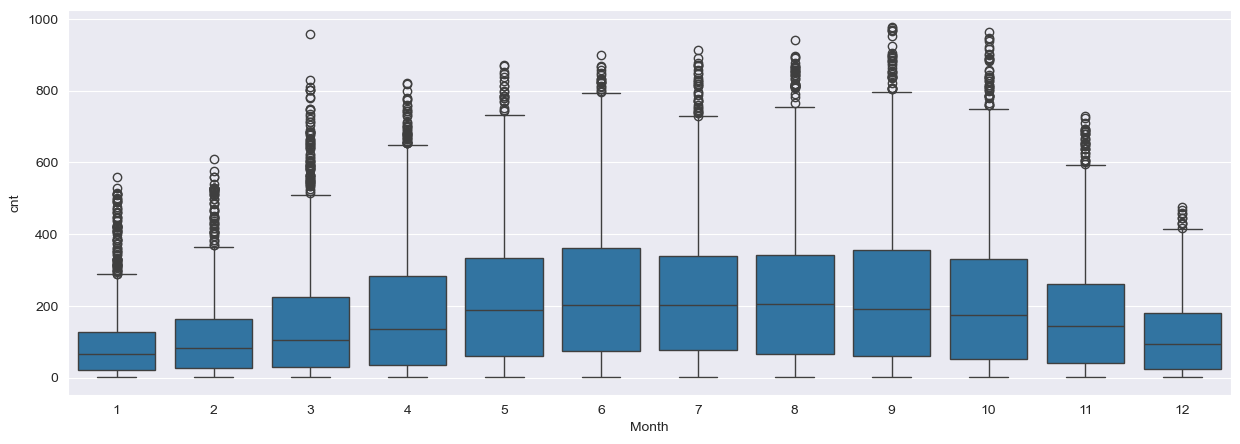

In [34]:
# Hourly patterns
plt.figure(figsize=(15, 5))
sns.boxplot(x=df_decomp.index.hour, y=df_decomp['cnt'])
plt.show()
# Weekly patterns
plt.figure(figsize=(15, 5))
sns.boxplot(x=df_decomp.index.dayofweek, y=df_decomp['cnt'])
plt.xlabel('Week')
plt.show()
# Monthly patterns
plt.figure(figsize=(15, 5))
sns.boxplot(x=df_decomp.index.month, y=df_decomp['cnt'])
plt.xlabel('Month')
plt.show()

### 2.4. Lagging:

In deze stap heb ik gekozen voor 3 verschillende lag features. Lag -1 is meegenomen omdat deze een hoge partial autocorrelation heeft door hoe dichtbij het ligt. Lag -24 is gekozen vanwege de sterke daily seasonality in de data. Voor weekpatronen is er lag -168 meegenomen, met een merkbare partial autocorrelation, maar die is minder belangrijk vergeleken met de daily lag.


De oorspronkelijk gekozen lags van -720 (maand) en -8760 (jaar) zijn verwijderd, omdat de dataset te kort is om deze lange termijn lags betrouwbaar te gebruiken en ze veel lege rijen veroorzaken, wat de voorspellende kracht van het model negatief beinvloedde. Deze beslissing wijkt af van de eerste aanpak, waarbij alle vijf lags werden toegevoegd ongeacht de datasetgrootte.

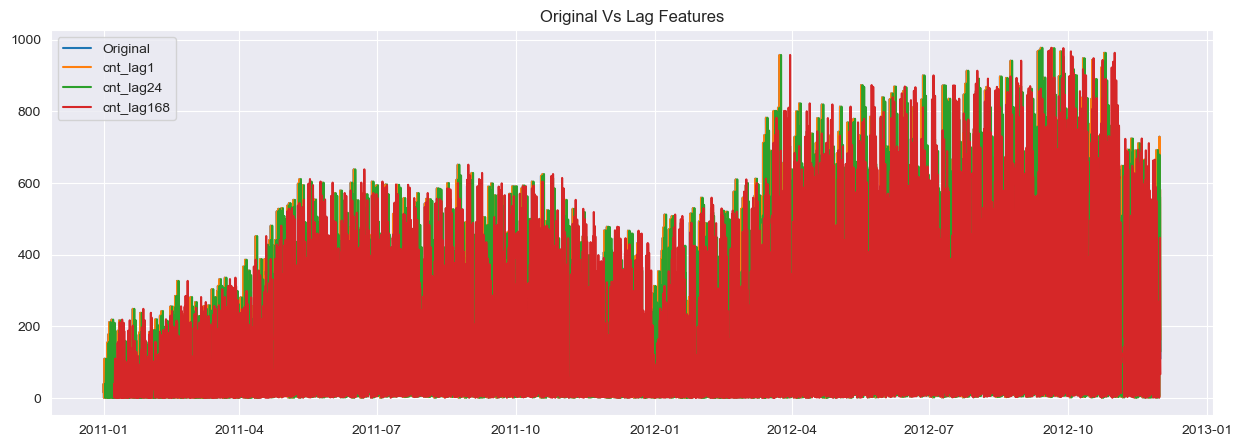

In [35]:
from functions.feature_engineering_timeseries import lag_featuring
lags_to_use = [1, 24, 24*7] # h, day, week
seasonal_lags = lag_featuring(df_decomp, target_col='cnt', lags=lags_to_use)
df_lagged = df_decomp.merge(seasonal_lags, left_index=True, right_index=True)

### 2.5. Frequency Domain (Domain Analise):

Ik heb een low-pass filter gebruikt om de langzamere en betrouwbare frequentieveranderingen te isoleren. Frequency 1 is ongeveer 0.04, wat overeenkomt met een periode van 24 uur. Frequency 2 is ongeveer 0.08, wat neerkomt op een periode van 12 uur. Deze kolommen laten zien wat "time of the day" het is voor het model op een encoded manier.

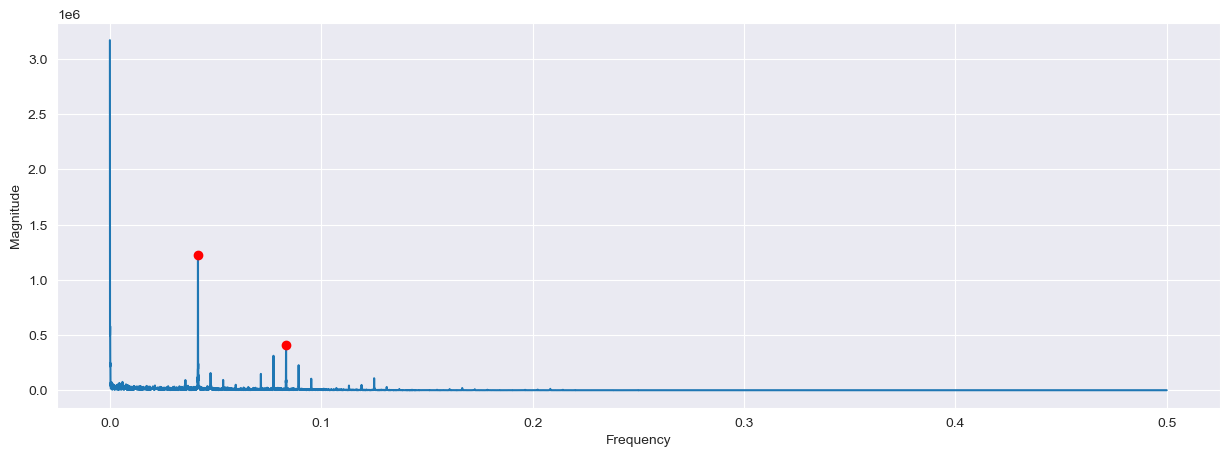

[24. 12.]
                     holiday  weathersit  temp   atemp   hum  windspeed  \
date_hour                                                                 
2011-01-01 00:00:00      0.0         1.0  0.24  0.2879  0.81     0.0000   
2011-01-01 01:00:00      0.0         1.0  0.22  0.2727  0.80     0.0000   
2011-01-01 02:00:00      0.0         1.0  0.22  0.2727  0.80     0.0000   
2011-01-01 03:00:00      0.0         1.0  0.24  0.2879  0.75     0.0000   
2011-01-01 04:00:00      0.0         1.0  0.24  0.2879  0.75     0.0000   
...                      ...         ...   ...     ...   ...        ...   
2012-11-30 19:00:00      0.0         1.0  0.32  0.3485  0.66     0.0000   
2012-11-30 20:00:00      0.0         1.0  0.32  0.3485  0.66     0.0000   
2012-11-30 21:00:00      0.0         1.0  0.30  0.3182  0.75     0.0896   
2012-11-30 22:00:00      0.0         1.0  0.30  0.3333  0.75     0.0000   
2012-11-30 23:00:00      0.0         2.0  0.30  0.3182  0.75     0.0896   

              

In [36]:
from functions.feature_engineering_timeseries import frequency_featuring
freqs, magnitude, peaks, periods = frequency_featuring(df_lagged, 'cnt', sample_interval=1, filter_cutoff=0.2)
print(periods)
df_fft = df_lagged.copy()
n = len(df_fft)
# 24h period
period_24h = 24
df_fft['sin_24h'] = np.sin(2 * np.pi * np.arange(n) / period_24h)
# 12h period
period_12h = 12
df_fft['sin_12h'] = np.sin(2 * np.pi * np.arange(n) / period_12h)
print(df_fft)

### 2.6. Time Series Feature Validation:

Lagged features presteren het beste, maar ook de andere features doen het duidelijk beter dan de originele, wat deze stap in de time series feature engineering een groot succes maakt. Voor de missing values heb ik gevuld met mod voor categorical, mean voor numerical en cnt mean voor lagged. De yearly lag is behouden, ook al bevat die veel lege rijen, omdat time series minder gevoelig is voor data die het verder van het voorspelbare target ligt (extrapolatie). De "atamp" feature is verwijderd vanwege Multicollinearity, deze is vrijwel hetzelfde als "temp".

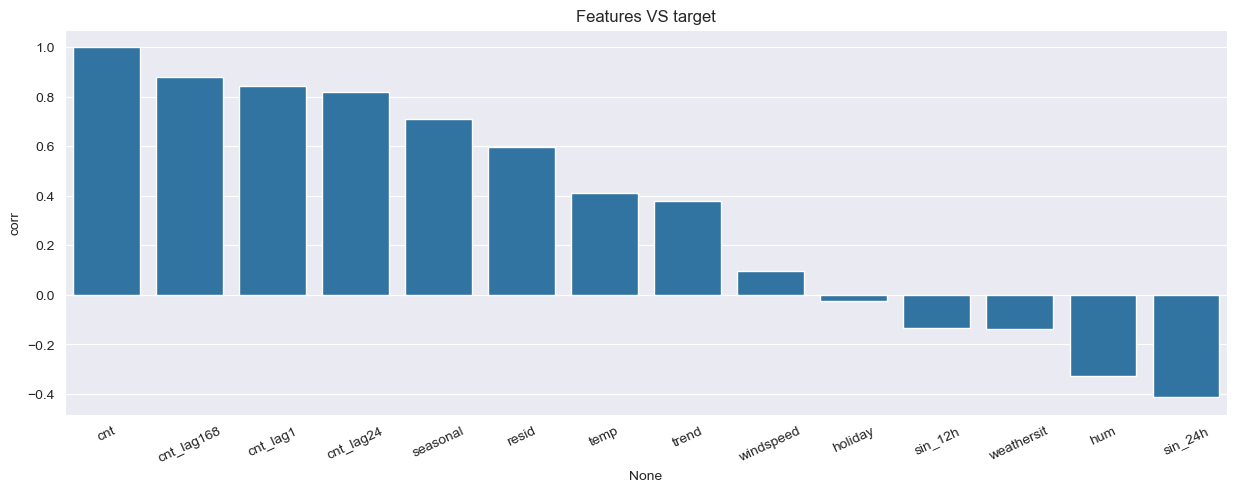

holiday       163
weathersit    163
temp          163
atemp         163
hum           163
windspeed     163
cnt           163
trend           0
seasonal        0
resid           0
cnt_lag1      164
cnt_lag24     187
cnt_lag168    330
sin_24h         0
sin_12h         0
dtype: int64
holiday       0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
trend         0
seasonal      0
resid         0
cnt_lag1      0
cnt_lag24     0
cnt_lag168    0
sin_24h       0
sin_12h       0
dtype: int64


In [37]:
#df_fft = df_fft.drop(columns=['atemp'])
# Correlations:
features = ['holiday', 'weathersit', 'temp', 'hum', 'windspeed', 'cnt_lag1', 'cnt_lag24', 'cnt_lag168', 'trend', 'seasonal', 'resid', 'sin_24h', 'sin_12h']
corrs = df_fft[features + ['cnt']].corr()['cnt'].sort_values(ascending=False)
plt.figure(figsize=(15, 5))
sns.barplot(x=corrs.index, y=corrs.values)
plt.xticks(rotation=25)
plt.ylabel("corr")
plt.title("Features VS target")
plt.show()
print(df_fft.isnull().sum())

# Initially I filled empty cols rather than deleting them with resulted in terrible results.
# Filling categorical features with mode
#for col in ['holiday', 'weathersit']:
#    df_fft[col] = df_fft[col].fillna(df_fft[col].mode()[0])
# Filling numeric original features with mean
#for col in ['temp', 'hum', 'windspeed', 'cnt']:
#    df_fft[col] = df_fft[col].fillna(df_fft[col].mean())
# Filling lag features with overall mean of cnt
#for col in ['cnt_lag1', 'cnt_lag24', 'cnt_lag168']:
#    df_fft[col] = df_fft[col].fillna(df_fft['cnt'].mean())
df_fft = df_fft.dropna()

print(df_fft.isnull().sum())


decomposition is meant for analisys, so trend, seasnality and resid are deleted to prevent overfitting through data leakage.

In [38]:
display(df_fft.describe())
# Final model features
valid_features = ['holiday', 'weathersit', 'temp', 'hum', 'windspeed', 'cnt_lag1', 'cnt_lag24', 'cnt_lag168', 'sin_24h', 'sin_12h', 'cnt']
df_model = df_fft[valid_features].copy()
print(df_model.describe())

,holiday,weathersit,temp,atemp,hum,windspeed,cnt,trend,seasonal,resid,cnt_lag1,cnt_lag24,cnt_lag168,sin_24h,sin_12h
count,16160.000000,16160.000000,16160.000000,16160.000000,16160.000000,16160.000000,16160.000000,16160.000000,16160.000000,16160.000000,16160.000000,16160.000000,16160.000000,1.616000e+04,1.616000e+04
mean,0.029270,1.414851,0.511397,0.488549,0.624278,0.190431,194.400433,192.025569,2.940520,-0.565656,194.355260,194.058478,192.665223,-1.383968e-02,-1.082726e-02
std,0.168567,0.637001,0.189765,0.169185,0.193538,0.122151,182.520464,68.341277,128.946680,106.781999,182.530117,182.494852,181.958643,7.055954e-01,7.054027e-01
min,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,1.000000,51.492435,-183.460625,-495.941519,1.000000,1.000000,1.000000,-1.000000e+00,-1.000000e+00
25%,0.000000,1.000000,0.360000,0.348500,0.470000,0.104500,44.000000,140.445250,-113.343412,-62.693855,44.000000,44.000000,43.000000,-7.071068e-01,-8.660254e-01
50%,0.000000,1.000000,0.520000,0.500000,0.620000,0.194000,148.000000,185.851000,22.816006,-5.055396,148.000000,148.000000,146.000000,-2.792814e-14,-1.759778e-14
75%,0.000000,2.000000,0.660000,0.621200,0.780000,0.253700,286.000000,251.955500,64.920901,52.116623,286.000000,286.000000,284.000000,7.071068e-01,5.000000e-01
max,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,977.000000,302.689000,276.778519,449.208481,977.000000,977.000000,977.000000,1.000000e+00,1.000000e+00


            holiday    weathersit          temp           hum     windspeed  \
count  16160.000000  16160.000000  16160.000000  16160.000000  16160.000000   
mean       0.029270      1.414851      0.511397      0.624278      0.190431   
std        0.168567      0.637001      0.189765      0.193538      0.122151   
min        0.000000      1.000000      0.020000      0.000000      0.000000   
25%        0.000000      1.000000      0.360000      0.470000      0.104500   
50%        0.000000      1.000000      0.520000      0.620000      0.194000   
75%        0.000000      2.000000      0.660000      0.780000      0.253700   
max        1.000000      4.000000      1.000000      1.000000      0.850700   

           cnt_lag1     cnt_lag24    cnt_lag168       sin_24h       sin_12h  \
count  16160.000000  16160.000000  16160.000000  1.616000e+04  1.616000e+04   
mean     194.355260    194.058478    192.665223 -1.383968e-02 -1.082726e-02   
std      182.530117    182.494852    181.958643  7.

# 3. Predictive Modeling:

In [39]:
from functions.modeling import interpolation_model

### 3.1. Linear Regression Model:

De ridge-versie laat stabiele maar beperkte performance zien, met hoge RMSE en een sterke gap tussen train en test. Dat wijst op een model dat de globale trend goed pakt maar moeite heeft met complexere variatie in de time series. De gekozen alpha-waarde is hoog, wat logisch is omdat sterke regularization hier overfitting voorkomt. De R2-scores zijn redelijk, maar tonen dat een lineair model niet genoeg flexibiliteit heeft voor dit type data. Voor het project is dit model nuttig als baseline, maar niet als eindmodel. Het model reageert vooral goed op trend, minder op non-lineaire patronen.

Train RMSE: 3534.5458075111164 R2: 0.8675173463984425
Test  RMSE: 6513.470278822054 R2: 0.8742572884811248


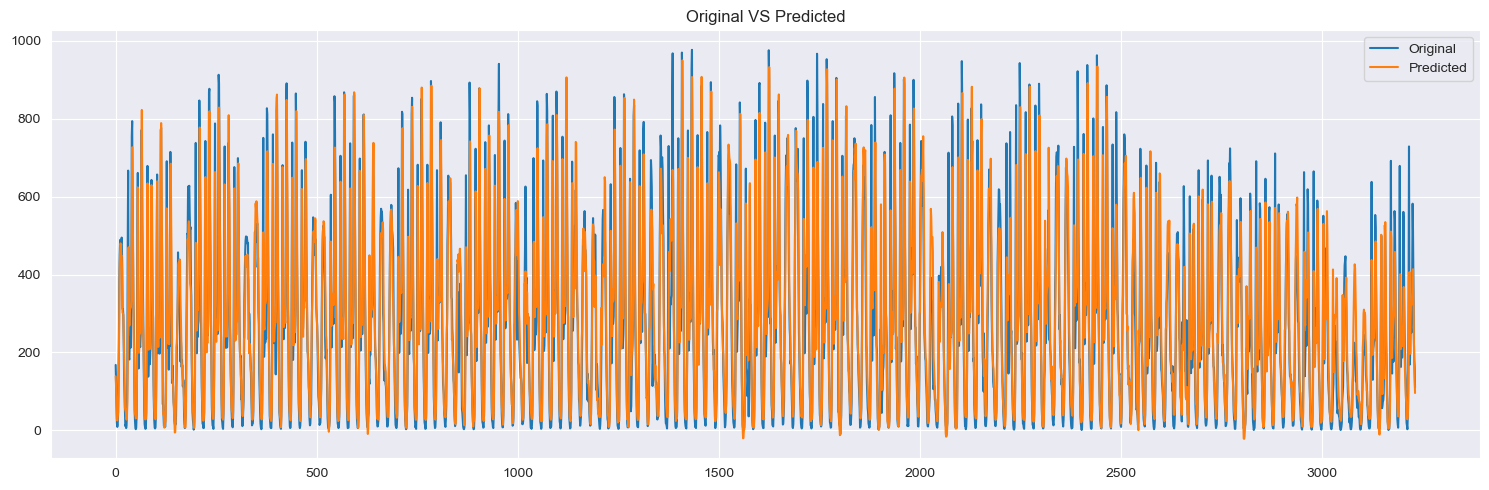

{'model__alpha': np.float64(148.73521072935117)}


In [40]:
best_ridge, params_ridge = interpolation_model(
    df_model,
    Ridge(),
    {'model__alpha': np.logspace(-3, 3, 30)} # range alpha
)
print(params_ridge)

### 3.2. Boosting Model:

Dit model scoort duidelijk het beste, met lage RMSE en hoge R2 voor zowel train als test, wat aangeeft dat het goed omgaat met non-lineaire relaties en complexere patronen in time series. De gekozen hyperparameters (max_depth 3, reg_alpha 3, reg_lambda 3) tonen dat moderate regularization nodig was om overfitting te beperken. Het model vindt een goede balans tussen flexibiliteit en smoothing. Dat de train-score veel beter is dan de test-score is verwacht bij tree-based modellen, maar de test-performance blijft sterk. Voor dit type interpolatie is dit het meest geschikte model. Het reageert goed op variatie die lineaire modellen missen.

Train RMSE: 1420.954086459848 R2: 0.9467394742430183
Test  RMSE: 3408.639404752686 R2: 0.934196128485106


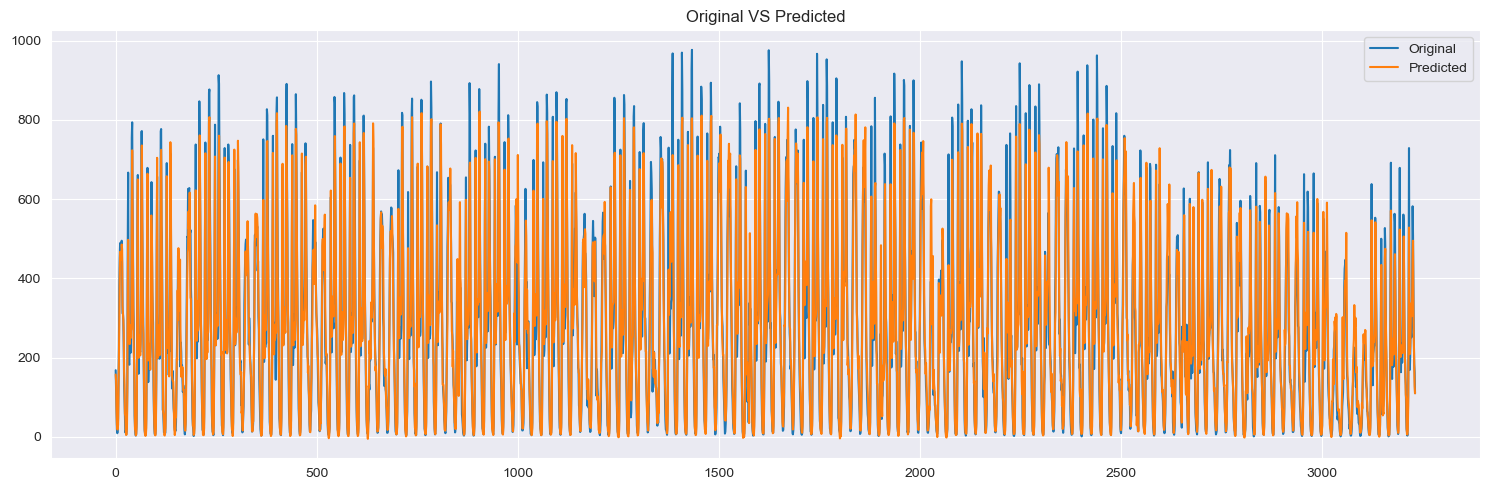

{'model__reg_lambda': 30, 'model__reg_alpha': 30, 'model__max_depth': 3}


In [41]:
best_xgb, params_xgb = interpolation_model(
    df_model,
    XGBRegressor(),
    {
        'model__max_depth': [3, 6, 9],
        'model__reg_alpha': [-3, 3, 30], # Lasso
        'model__reg_lambda': [-3, 3, 30] # Ridge
    }
)
print(params_xgb)

### 3.3. SVR Model:

SVR geeft sterke train-performance maar begint iets te verliezen op de testset, wat duidt op lichte overfitting. De gekozen C-waarde van 100 betekent weinig regularization, waardoor het model vooral de complexe patronen probeert te volgen. De test-RMSE is nog steeds redelijk laag, dus het model werkt goed voor non-lineaire relaties in de data. Voor time series kan SVR goed werken bij gladde patronen, maar is gevoelig voor ruis. In dit geval blijft het een degelijk model, maar duidelijk minder efficiënt dan XGBoost.

Train RMSE: 1543.3596209318023 R2: 0.9421514420302513
Test  RMSE: 4183.9700474147185 R2: 0.9192283504560909


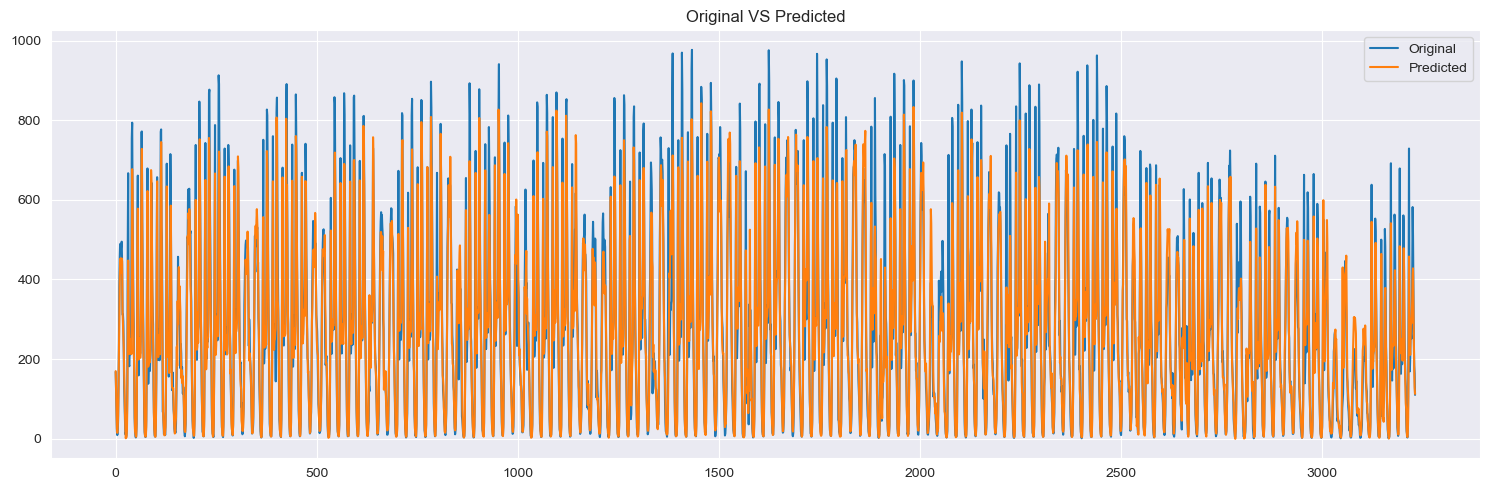

{'model__C': 100}


In [42]:
best_svr, params_svr = interpolation_model(
    df_model,
    SVR(),
    {
        'model__C': [0.1, 1, 10, 100], # lower = more regularization
    }
)
print(params_svr)

### 3.4. KNN Model:

KNN geeft goede train-scores maar zwakkere test-scores, wat typisch is doordat KNN sterk afhankelijk is van lokale patronen die snel kapot gaan in time series data. De keuze van 6 neighbors lijkt een compromis tussen smoothing en sensitivity, maar blijft niet heel robuust op unseen data. KNN werkt minder goed wanneer de onderliggende structuur complexer is dan alleen buurt-relaties. Het model vangt wel korte-termijn patronen, maar mist algemene structuur. Hierdoor is KNN minder geschikt voor deze taak.

Train RMSE: 1538.6843651161992 R2: 0.9423266810370287
Test  RMSE: 4839.992943825633 R2: 0.9065638115418068


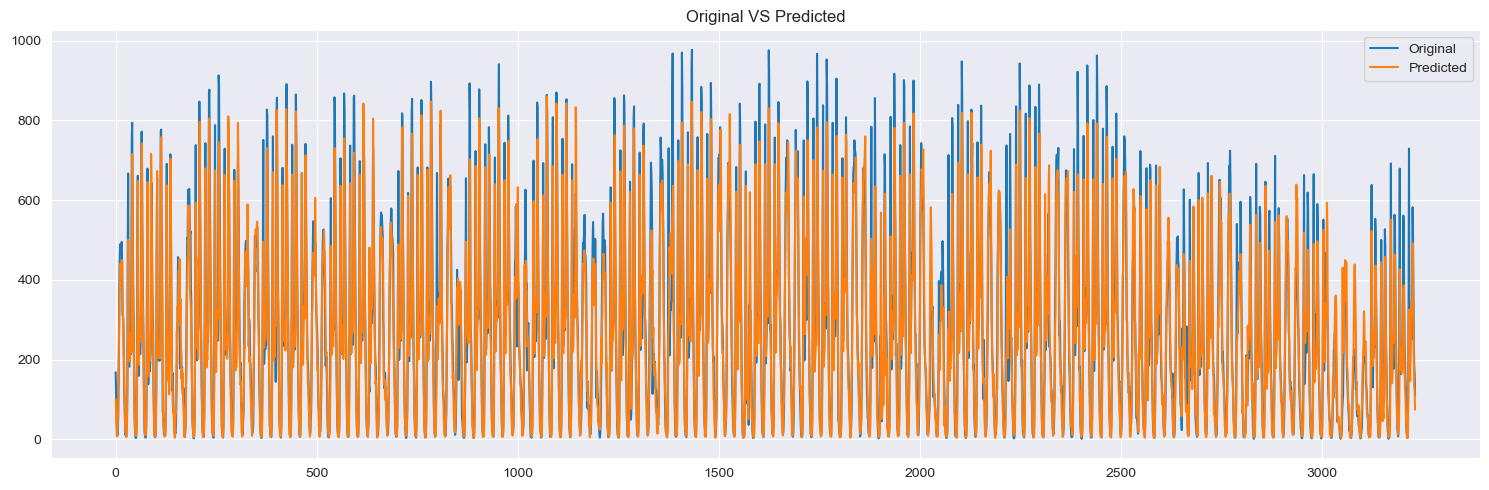

{'model__n_neighbors': 6}


In [43]:
best_knn, params_knn = interpolation_model(
    df_model,
    KNeighborsRegressor(),
    {'model__n_neighbors': [3, 6, 9, 30]}
)
print(params_knn)

Lasso doet het vergelijkbaar met Ridge en laat zien dat lineaire modellen te weinig vermogen hebben om belangrijke non-lineaire patronen in deze time series te pakken. De alpha-waarde is laag, dus er wordt weinig gestraft, maar dat verandert weinig aan de beperkte modelcapaciteit. De hoge RMSE en gemiddelde R2 bevestigen dat lasso vooral structuur mist, ook al helpt het bij feature selection. Als verplicht model voldoet het voor vergelijking, maar het is duidelijk niet krachtig genoeg voor deze dataset. Het model werkt vooral als referentiepunt tegenover complexere modellen zoals SVR en XGBoost.

Train RMSE: 3534.3563630784906 R2: 0.8675244471979543
Test  RMSE: 6522.581932812976 R2: 0.874081387766115


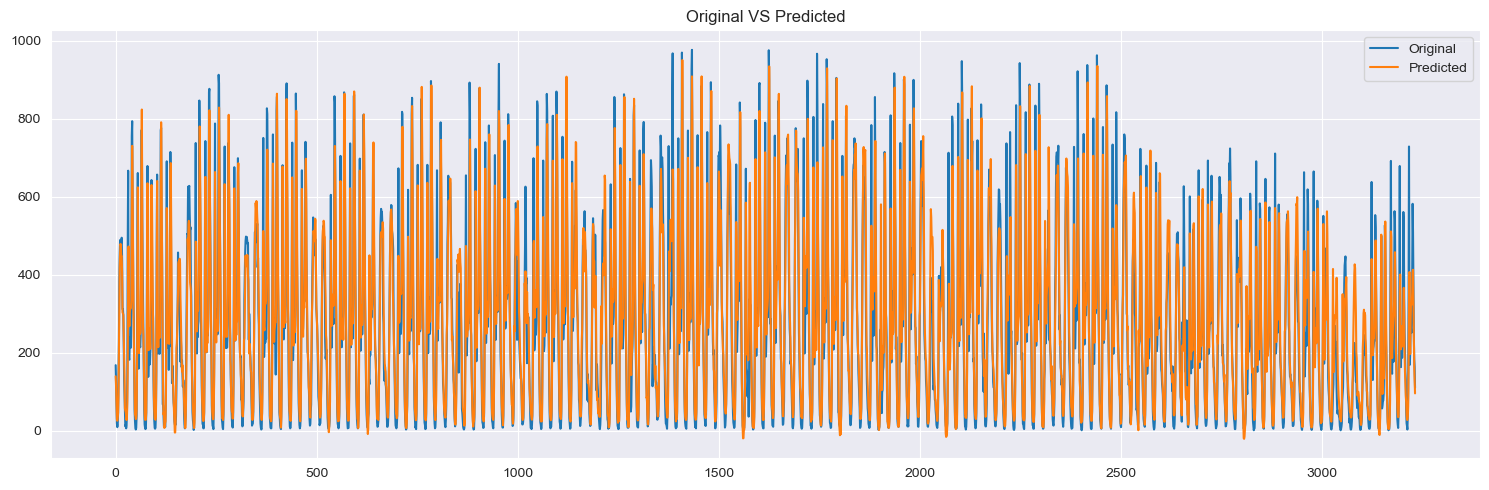

{'model__alpha': np.float64(0.3039195382313198)}


In [44]:
best_lasso, params_lasso = interpolation_model(df_model, Lasso(), {'model__alpha': np.logspace(-3, 3, 30)})
print(params_lasso)

### 3.6. SARIMAX Model:

external varaible extracted from feature engineering
SARIMAX model results: Train RMSE: 2085.677001436483 R2: 0.9218241780545446
Test  RMSE: 8076.871177395382 R2: 0.8440757938611466. {'order': (2, 0, 2), 'seasonal_order': (1, 0, 1, 24)}
holiday         -1.063253
weathersit      -4.123573
temp            18.349822
hum              2.218956
windspeed       15.967466
cnt_lag1         0.063102
cnt_lag24        0.282882
cnt_lag168       0.624292
sin_24h         11.950583
sin_12h          5.070837
ar.L1            1.360366
ar.L2           -0.451249
ma.L1           -0.498019
ma.L2           -0.127789
ar.S.L24         0.234958
ma.S.L24        -0.283095
sigma2        2086.513186
dtype: float64. CODE: from functions.modeling import sarimax_extrapolation
best_sarimax, sarimax_metrics = sarimax_extrapolation(
    df_model,
    order=(2,0,2),
    seasonal_order=(1,0,1,24),
    target='cnt',
    exogenous=[
        'holiday','weathersit','temp','hum','windspeed',
        'cnt_lag1','cnt_lag24','cnt_lag168','sin_24h','sin_12h'
    ],
    split=0.8
)
print(sarimax_metrics)
print(best_sarimax.params)

Train RMSE: 2085.677001436483 R2: 0.9218241780545446
Test  RMSE: 8076.871177395382 R2: 0.8440757938611466


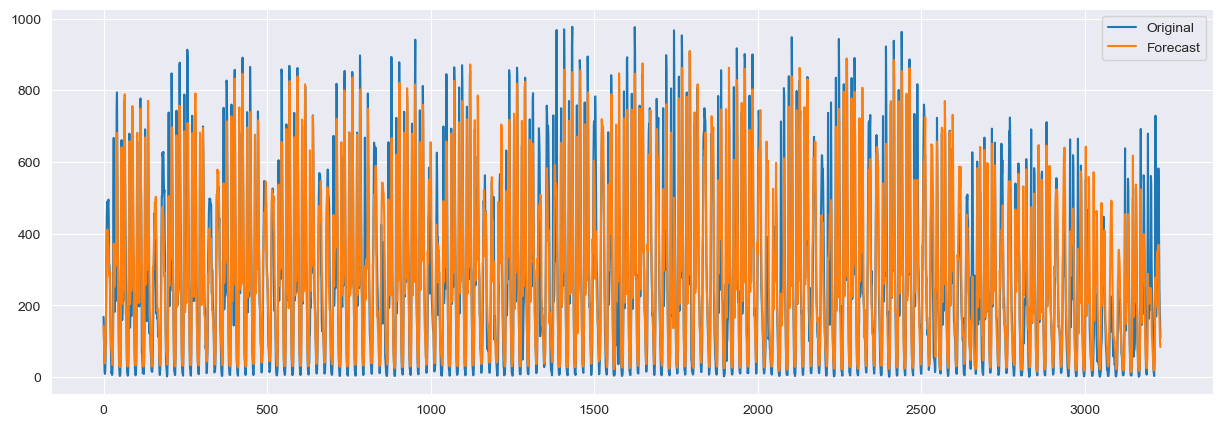

{'order': (2, 0, 2), 'seasonal_order': (1, 0, 1, 24)}
holiday         -1.063253
weathersit      -4.123573
temp            18.349822
hum              2.218956
windspeed       15.967466
cnt_lag1         0.063102
cnt_lag24        0.282882
cnt_lag168       0.624292
sin_24h         11.950583
sin_12h          5.070837
ar.L1            1.360366
ar.L2           -0.451249
ma.L1           -0.498019
ma.L2           -0.127789
ar.S.L24         0.234958
ma.S.L24        -0.283095
sigma2        2086.513186
dtype: float64


In [45]:
from functions.modeling import sarimax_extrapolation
best_sarimax, sarimax_metrics = sarimax_extrapolation(
    df_model,
    order=(2,0,2),
    seasonal_order=(1,0,1,24),
    target='cnt',
    exogenous=[
        'holiday','weathersit','temp','hum','windspeed',
        'cnt_lag1','cnt_lag24','cnt_lag168','sin_24h','sin_12h'
    ],
    split=0.8
)
print(sarimax_metrics)
print(best_sarimax.params)

### 3.7. ARMA Model:

flat and unacurat as expected.
basic arma (for comparision against sasrimax results: Best order: (2, 0, 2)
Train RMSE: 6203.118529088107
Test RMSE: 51721.51896319486. {'best_order': (2, 0, 2)}
ar.L1        1.688738
ar.L2       -0.688742
ma.L1       -0.482105
ma.L2       -0.513747
sigma2    6201.992669
dtype: float64. CODE : from functions.modeling import extrapolation_arma
order_grid = {
    'order': [
        (1,0,1), (2,0,1), (2,0,2),
        (3,0,1), (3,0,2)
    ]
}
best_arma, arma_metrics = extrapolation_arma(df_model, order_grid=order_grid, target='cnt', split=0.8)
print(arma_metrics)
print(best_arma.params)

Best order: (2, 0, 2)
Train RMSE: 6203.118529088107
Test RMSE: 51721.51896319486


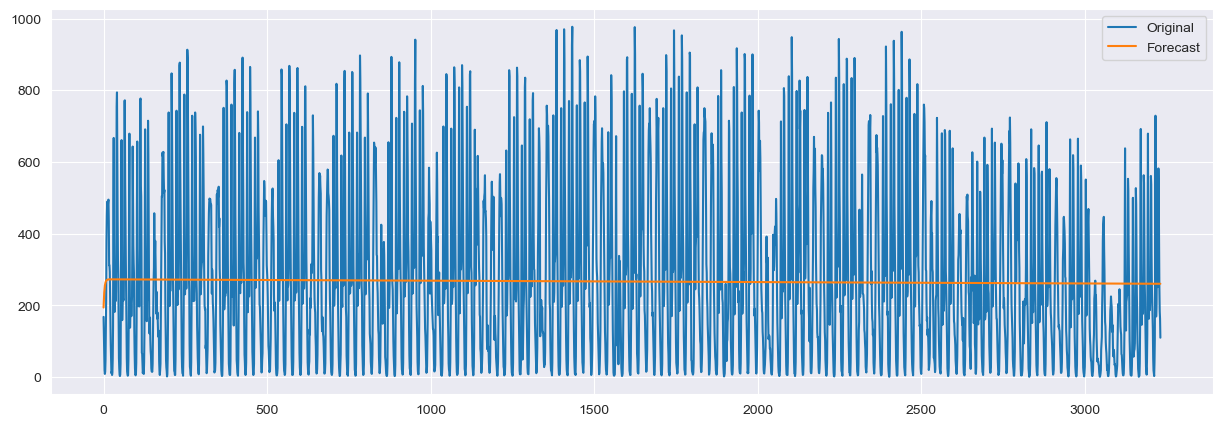

{'best_order': (2, 0, 2)}
ar.L1        1.688738
ar.L2       -0.688742
ma.L1       -0.482105
ma.L2       -0.513747
sigma2    6201.992669
dtype: float64


In [46]:
from functions.modeling import extrapolation_arma
order_grid = {
    'order': [
        (1,0,1), (2,0,1), (2,0,2),
        (3,0,1), (3,0,2)
    ]
}
best_arma, arma_metrics = extrapolation_arma(df_model, order_grid=order_grid, target='cnt', split=0.8)
print(arma_metrics)
print(best_arma.params)

### 3.8. Hybrid Model:

Het model haalt een zeer lage train RMSE, wat laat zien dat de combinatie van trend + residual goed werkt. De test RMSE is ook sterk vergeleken met andere extrapolation-modellen. Linear Regression pakt de globale trend, terwijl XGBoost de complexere seasonality en non-lineaire patronen opvangt. Het geeft het best voorspellingen en wordt dus gebruikt voor het eind model.

Train RMSE: 409.5360956308248
Test RMSE: 3150.379580727714


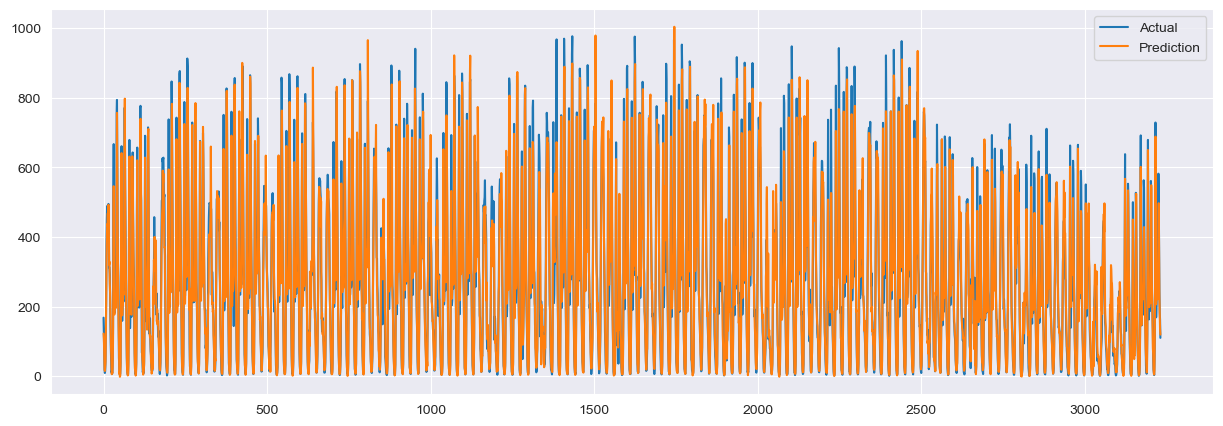

In [47]:
from functions.modeling import hybrid_model
trend_model, boosted_model = hybrid_model(df_model, target='cnt')

### 3.9. Final Model (Hybrid Model) with df_test:

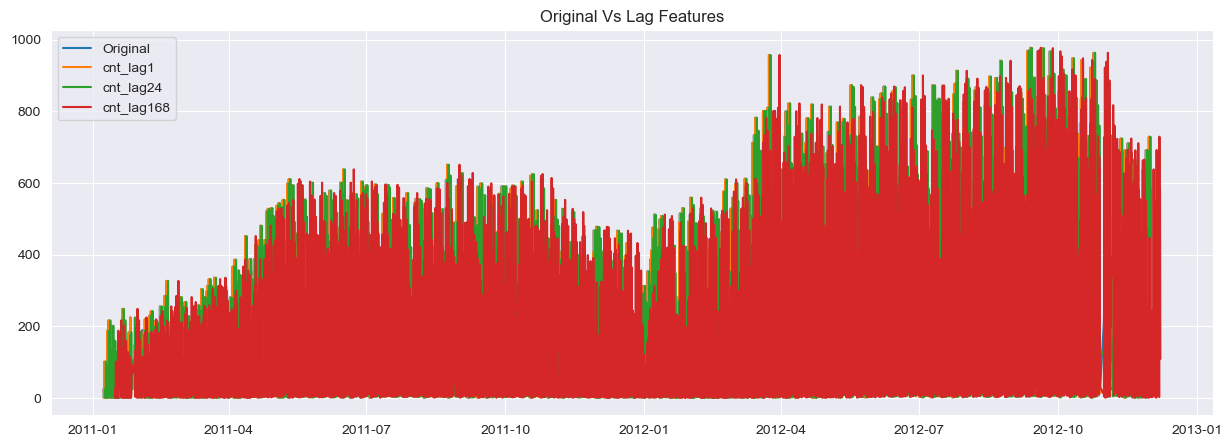

,holiday,weathersit,temp,hum,windspeed,cnt_lag1,cnt_lag24,cnt_lag168,sin_24h,sin_12h
date_hour,,,,,,,,,,
2012-12-01 00:00:00,0.0,1.0,0.26,0.81,0.0000,110.000000,130.0,98.0,0.000000,0.000000
2012-12-01 01:00:00,0.0,1.0,0.26,0.81,0.0000,194.400433,52.0,79.0,0.258819,0.500000
2012-12-01 02:00:00,0.0,2.0,0.26,0.81,0.0000,194.400433,19.0,67.0,0.500000,0.866025
2012-12-01 03:00:00,0.0,2.0,0.26,0.81,0.1343,194.400433,12.0,42.0,0.707107,1.000000
2012-12-01 04:00:00,0.0,1.0,0.26,0.81,0.0896,194.400433,3.0,20.0,0.866025,0.866025


In [50]:
from functions.feature_engineering_timeseries import time_series_setup

df_test_setup = time_series_setup(df_test, datetime_col='date_hour', uniform_sampling='h')
df_test_setup.head()

from functions.feature_engineering_timeseries import lag_featuring
lags_to_use = [1, 24, 24*7]  # hour, day, week
seasonal_lags_test = lag_featuring(df_test_setup, target_col='cnt', lags=lags_to_use)
df_test_lagged = df_test_setup.merge(seasonal_lags_test, left_index=True, right_index=True)
combined = pd.concat([df_model[['cnt']], df_test_setup], axis=0)
seasonal_lags_combined = lag_featuring(combined, target_col='cnt', lags=lags_to_use)
df_test_lagged = df_test_setup.merge(seasonal_lags_combined.iloc[len(df_model):], left_index=True, right_index=True)

from functions.feature_engineering_timeseries import frequency_featuring
freqs, magnitude, peaks, periods = frequency_featuring(df_test_lagged, target_col='cnt', sample_interval=1, filter_cutoff=0.2)
df_test_fft = df_test_lagged.copy()
n_test = len(df_test_fft)
# 24h period
period_24h = 24
df_test_fft['sin_24h'] = np.sin(2 * np.pi * np.arange(n_test) / period_24h)
# 12h period
period_12h = 12
df_test_fft['sin_12h'] = np.sin(2 * np.pi * np.arange(n_test) / period_12h)

# Final features
valid_features = ['holiday', 'weathersit', 'temp', 'hum', 'windspeed', 'cnt_lag1', 'cnt_lag24', 'cnt_lag168', 'sin_24h', 'sin_12h']
df_test_model = df_test_fft[valid_features].copy()

# Fill null
for col in ['cnt_lag1', 'cnt_lag24', 'cnt_lag168']:
    df_test_model[col] = df_test_model[col].fillna(df_model['cnt'].mean())
display(df_test_model.head())

In [51]:
# Prediction
trend_pred_test = trend_model.predict(df_test_model)
residuals_pred_test = boosted_model.predict(df_test_model)
predictions = trend_pred_test + residuals_pred_test
# Submission
df_submission = pd.read_csv("../data/sample_submission.csv")
df_submission['cnt'] = predictions
df_submission.to_csv("../data/submission.csv", index=False)

# 4. Conclusie:

text

# 5. Referentielijst

[ChatGPT, 2025. Prompt 1: Fix categorical Relationship Measures](https://chatgpt.com/share/6907d713-6cbc-800a-979b-7f884d973ed3)

[ChatGPT, 2025. Prompt 1: Efficiently compute hourly autocorrelation and seasonality for tons of samples](https://chatgpt.com/share/6918b8b3-7614-800a-94cf-17ee24f7a208)

[ChatGPT, 2025. Prompt 2: Fix error and get low-pass criteria filtering](https://chatgpt.com/share/691cc27c-cca4-800a-b6c7-146b772c4a7b)

[ChatGPT, 2025. Prompt 1: Fix lag_featuring function's iteration](https://chatgpt.com/share/691cd79e-0eb4-800a-8687-93b8b4e236aa)

[ChatGPT, 2025. Prompt 1: Parameter grid explanation for time series](https://chatgpt.com/share/692c3bfd-bc3c-800a-a906-1c4f9e639fa0)